



**Machine Learning Laboratory**  
**Suggested duration:** 3 hours  
**Implementation language:** Python with NumPy  


This notebook develops a feedforward neural network from first principles. The guided lesson uses a nonlinear two-moons dataset so that the role of the hidden layer is easy to visualize. The graded assignment then applies the same mathematics to the Breast Cancer Wisconsin dataset.

---

## Learning objectives

After this session, a student should be able to:

1. explain the structure of an input, hidden, and output layer;
2. calculate the output of a neuron using weights, bias, and an activation function;
3. implement forward propagation using matrix operations;
4. calculate binary cross-entropy loss;
5. derive and implement backpropagation using the chain rule;
6. update parameters using gradient descent;
7. verify analytical gradients using numerical gradient checking;
8. train and evaluate a binary classifier; and
9. interpret learning curves, decision boundaries, and classification metrics.

## 1. From a neuron to a feedforward neural network

A neuron first calculates a weighted sum and then applies an activation function:

$$
z = \sum_{j=1}^{d}x_jw_j+b = \mathbf{x}^{T}\mathbf{w}+b,
\qquad a=g(z).
$$

For a network with one hidden layer, information moves only in the forward direction:

$$
\mathbf{X}
\rightarrow \mathbf{Z}^{[1]}
\rightarrow \mathbf{A}^{[1]}
\rightarrow \mathbf{Z}^{[2]}
\rightarrow \hat{\mathbf{y}}.
$$

- The **input layer** receives features.
- The **hidden layer** learns intermediate nonlinear representations.
- The **output layer** returns a probability for binary classification.
- A network is called **fully connected** or **dense** when every neuron in one layer connects to every neuron in the next layer.

## 2. Mathematical notation and tensor shapes

We use a one-hidden-layer network with $m$ examples, $d$ input features, $h$ hidden neurons, and one output neuron.

| Quantity | Meaning | Shape |
|---|---|---:|
| $\mathbf{X}$ | input matrix | $(m,d)$ |
| $\mathbf{W}^{[1]}$ | input-to-hidden weights | $(d,h)$ |
| $\mathbf{b}^{[1]}$ | hidden biases | $(1,h)$ |
| $\mathbf{Z}^{[1]}$ | hidden pre-activation | $(m,h)$ |
| $\mathbf{A}^{[1]}$ | hidden activation | $(m,h)$ |
| $\mathbf{W}^{[2]}$ | hidden-to-output weights | $(h,1)$ |
| $\mathbf{b}^{[2]}$ | output bias | $(1,1)$ |
| $\hat{\mathbf{y}}$ | predicted probability | $(m,1)$ |

The equations are:

$$
\begin{aligned}
\mathbf{Z}^{[1]} &= \mathbf{X}\mathbf{W}^{[1]}+\mathbf{b}^{[1]},\\
\mathbf{A}^{[1]} &= \operatorname{ReLU}(\mathbf{Z}^{[1]}),\\
\mathbf{Z}^{[2]} &= \mathbf{A}^{[1]}\mathbf{W}^{[2]}+\mathbf{b}^{[2]},\\
\hat{\mathbf{y}} &= \sigma(\mathbf{Z}^{[2]}).
\end{aligned}
$$

NumPy broadcasts each bias row across all $m$ examples.

## 3. Activation Functions

Activation functions introduce **non-linearity** into a neural network, allowing it to learn complex relationships between inputs and outputs.

### Sigmoid

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

$$
\sigma'(z)=\sigma(z)(1-\sigma(z))
$$

Sigmoid maps a number to $(0,1)$, so it is useful at the **binary output layer** when the output represents a probability.

Its derivative becomes very small for large positive or negative inputs, which can contribute to the **vanishing gradient problem**.

**Range:** $(0,1)$

**Advantages:**
- Smooth and differentiable
- Output can be interpreted as a probability
- Useful for binary classification output layers

**Disadvantages:**
- Suffers from vanishing gradients
- Not zero-centered
- More computationally expensive than ReLU

---

### Tanh

$$
\tanh(z)=\frac{e^z-e^{-z}}{e^z+e^{-z}}
$$

$$
\tanh'(z)=1-\tanh^2(z)
$$

Tanh maps the input to $(-1,1)$ and is **zero-centered**, which can make optimization easier than sigmoid.

However, like sigmoid, it can suffer from vanishing gradients for very large positive or negative inputs.

**Range:** $(-1,1)$

**Advantages:**
- Zero-centered
- Stronger gradients than sigmoid around $z=0$
- Useful in some recurrent neural networks

**Disadvantages:**
- Vanishing gradient for large $|z|$
- More computationally expensive than ReLU

---

### ReLU (Rectified Linear Unit)

$$
\operatorname{ReLU}(z)=\max(0,z)
$$

$$
\operatorname{ReLU}'(z)=
\begin{cases}
1,&z>0,\\
0,&z\leq0
\end{cases}
$$

ReLU is computationally simple and is widely used in **hidden layers**.

For positive inputs, its derivative is 1, which helps reduce the vanishing-gradient problem.

A neuron that consistently receives negative inputs can stop learning because its gradient becomes zero. This is known as the **dying ReLU problem**.

**Range:** $[0,\infty)$

**Advantages:**
- Simple and computationally efficient
- Helps reduce vanishing gradients for positive inputs
- Widely used in deep neural networks

**Disadvantages:**
- Dying ReLU problem
- Not zero-centered

---

### Leaky ReLU

$$
\operatorname{LeakyReLU}(z)=
\begin{cases}
z,&z>0,\\
\alpha z,&z\leq0
\end{cases}
$$

where $\alpha$ is a small positive constant, commonly $0.01$.

Its derivative is:

$$
\operatorname{LeakyReLU}'(z)=
\begin{cases}
1,&z>0,\\
\alpha,&z\leq0
\end{cases}
$$

Leaky ReLU allows a **small gradient for negative inputs**, reducing the dying ReLU problem.

**Advantages:**
- Reduces the dying ReLU problem
- Simple and computationally efficient
- Maintains a gradient for negative inputs

**Disadvantages:**
- Requires choosing $\alpha$
- Still not zero-centered

---

### ELU (Exponential Linear Unit)

$$
\operatorname{ELU}(z)=
\begin{cases}
z,&z>0,\\
\alpha(e^z-1),&z\leq0
\end{cases}
$$

ELU behaves like ReLU for positive values but approaches $-\alpha$ for negative values.

**Advantages:**
- Produces negative outputs
- Can provide smoother behavior than ReLU
- Reduces the dying-neuron problem

**Disadvantages:**
- More computationally expensive than ReLU
- Requires an $\alpha$ parameter

---

### Softmax

For a multi-class classification problem:

$$
\operatorname{Softmax}(z_i)
=
\frac{e^{z_i}}
{\sum_{j=1}^{K}e^{z_j}}
$$

where $K$ is the number of classes.

Softmax converts the output logits into **class probabilities** whose sum is 1.

$$
\sum_{i=1}^{K}\operatorname{Softmax}(z_i)=1
$$

It is commonly used in the **output layer for multi-class classification**.

**Advantages:**
- Produces a probability distribution over classes
- Useful for multi-class classification
- Commonly combined with cross-entropy loss

---

### Linear

$$
f(z)=z
$$

$$
f'(z)=1
$$

The linear activation simply returns the input without applying a non-linear transformation.

It is commonly used in the **output layer for regression problems**.

**Range:** $(-\infty,\infty)$

**Examples:**
- House price prediction
- Temperature prediction
- Salary prediction

---

## Quick Comparison

| Activation | Range | Common Use | Main Issue |
|------------|-------|------------|------------|
| **Sigmoid** | $(0,1)$ | Binary classification output | Vanishing gradient |
| **Tanh** | $(-1,1)$ | Hidden/RNN layers | Vanishing gradient |
| **ReLU** | $[0,\infty)$ | Hidden layers | Dying ReLU |
| **Leaky ReLU** | $(-\infty,\infty)$ | Hidden layers | Choosing $\alpha$ |
| **ELU** | $(-\alpha,\infty)$ | Hidden layers | More computation |
| **Softmax** | $(0,1)$ | Multi-class output | Can saturate |
| **Linear** | $(-\infty,\infty)$ | Regression output | No non-linearity |

---

## Typical Activation Function Choices

- **Hidden layers:** ReLU / Leaky ReLU
- **Binary classification output:** Sigmoid
- **Multi-class classification output:** Softmax
- **Regression output:** Linear

### Important for Backpropagation

During backpropagation, the **derivative of the activation function** is used to calculate how the error should be propagated backward through the network.

For example, for ReLU:

$$
\frac{\partial L}{\partial z}
=
\frac{\partial L}{\partial a}
\cdot
\operatorname{ReLU}'(z)
$$

Therefore, understanding both the **activation function and its derivative** is important for understanding backpropagation.

## 4. Import the required libraries

In [ ]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,average_precision_score,confusion_matrix,ConfusionMatrixDisplay,RocCurveDisplay,PrecisionRecallDisplay,
)

warnings.filterwarnings("ignore", category=UserWarning)
np.set_printoptions(precision=4, suppress=True)

RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


## 5. Guided demonstration dataset: two moons

The two-moons dataset is not linearly separable. A network without a nonlinear hidden layer cannot easily learn its curved class boundary. We use a stratified 70/15/15 split:

- 70% training data for learning parameters;
- 15% validation data for model decisions; and
- 15% test data for one final unbiased evaluation.

In [ ]:
X, y = make_moons(n_samples=1000, noise=0.25, random_state=RANDOM_STATE)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print("Training shape  :", X_train_s.shape, y_train.shape)
print("Validation shape:", X_val_s.shape, y_val.shape)
print("Test shape      :", X_test_s.shape, y_test.shape)
print("Training class counts:", np.bincount(y_train))

Training shape  : (700, 2) (700,)
Validation shape: (150, 2) (150,)
Test shape      : (150, 2) (150,)
Training class counts: [350 350]


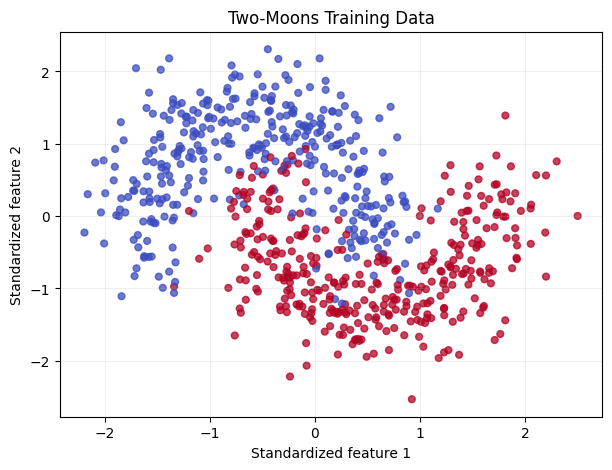

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(X_train_s[:, 0], X_train_s[:, 1], c=y_train, cmap="coolwarm", s=24, alpha=0.75)
plt.xlabel("Standardized feature 1")
plt.ylabel("Standardized feature 2")
plt.title("Two-Moons Training Data")
plt.grid(alpha=0.2)
plt.show()

## 6. Implement activation functions

Clipping the sigmoid input avoids numerical overflow when $z$ has very large magnitude. The derivative functions are required during backpropagation.

In [ ]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))


def sigmoid_derivative_from_activation(a):
    return a * (1.0 - a)


def relu(z):
    return np.maximum(0.0, z)


def relu_derivative(z):
    return (z > 0).astype(float)


sample_z = np.array([-2.0, -0.5, 0.0, 0.5, 2.0])
print("z             :", sample_z)
print("sigmoid(z)    :", sigmoid(sample_z))
print("ReLU(z)       :", relu(sample_z))
print("ReLU'(z)      :", relu_derivative(sample_z))

z             : [-2.  -0.5  0.   0.5  2. ]
sigmoid(z)    : [0.1192 0.3775 0.5    0.6225 0.8808]
ReLU(z)       : [0.  0.  0.  0.5 2. ]
ReLU'(z)      : [0. 0. 0. 1. 1.]


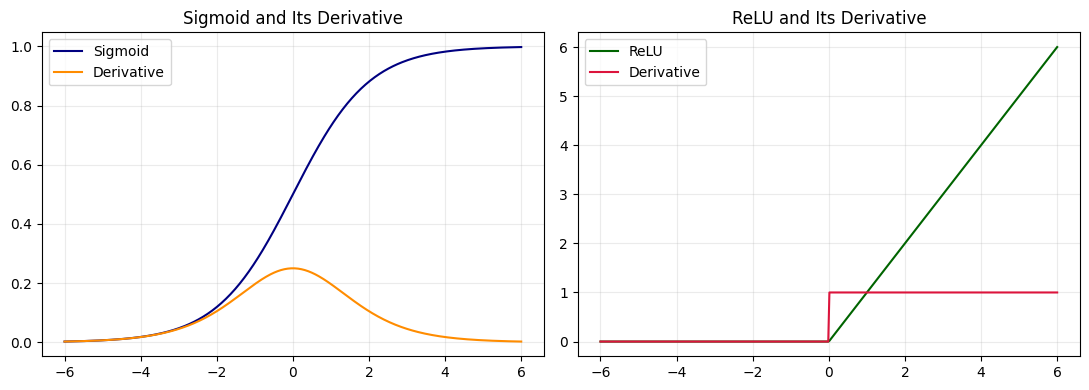

In [ ]:
z_values = np.linspace(-6, 6, 400)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(z_values, sigmoid(z_values), label="Sigmoid", color="navy")
axes[0].plot(z_values,sigmoid_derivative_from_activation(sigmoid(z_values)),label="Derivative",color="darkorange",)
axes[0].set_title("Sigmoid and Its Derivative")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(z_values, relu(z_values), label="ReLU", color="darkgreen")
axes[1].plot(z_values, relu_derivative(z_values), label="Derivative", color="crimson")
axes[1].set_title("ReLU and Its Derivative")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

# 7.Weight Initialization in Neural Networks

Weight initialization is the process of assigning **initial values to the weights** of a neural network before training begins.

For a layer:

$$
z = Wx+b
$$

where $W$ represents the weights and $b$ represents the biases.

Good initialization helps the network avoid **vanishing/exploding gradients** and allows the model to learn efficiently.

---

## 1. Zero Initialization

### Idea

Initialize every weight with zero:

$$
\boxed{W_{ij}=0}
$$

or

$$
\boxed{W=\mathbf{0}}
$$

Biases can also commonly be initialized to zero:

$$
b_i=0
$$

### What happens?

Suppose two neurons in the same hidden layer have:

$$
W_1=W_2=0
$$

They receive the same input and produce the same output. During backpropagation, they also receive the same gradient.

Therefore, they continue to have identical weights.

This is called the **symmetry problem**.

### When to use?

- Generally **not recommended for weights in hidden layers**.
- Zero initialization is commonly acceptable for **biases**.

### Main problem

$$
\boxed{\text{All neurons learn the same features}}
$$

---

# 2. Random Initialization

### Idea

Instead of giving every weight the same value, initialize weights with **small random values**.

For example:

$$
\boxed{
W_{ij}\sim\mathcal{N}(0,\sigma^2)
}
$$

or

$$
\boxed{
W_{ij}\sim U(-a,a)
}
$$

where the values are randomly sampled from a distribution.

### Why random?

Random initialization breaks the symmetry between neurons.

For example:

$$
W_1\neq W_2\neq W_3
$$

so different neurons can learn different features.

### When to use?

Random initialization is useful as a **basic/general initialization approach**, especially for simple neural networks.

However, choosing the variance $\sigma^2$ arbitrarily can lead to:

- Very small activations → vanishing gradients
- Very large activations → exploding gradients

Therefore, modern neural networks usually use more carefully designed methods such as **Xavier or He initialization**.

### Main idea

$$
\boxed{
\text{Random weights}
\rightarrow
\text{Break symmetry}
\rightarrow
\text{Different neurons learn different features}
}
$$

---

# 3. Xavier (Glorot) Initialization

### Idea

Xavier initialization chooses the scale of the weights based on both:

- $n_{in}$: number of input neurons
- $n_{out}$: number of output neurons

The goal is to keep the **variance of activations and gradients reasonably stable across layers**.

### Xavier Normal

$$
\boxed{
W_{ij}\sim
\mathcal{N}
\left(
0,
\frac{2}{n_{in}+n_{out}}
\right)
}
$$

Therefore,

$$
\boxed{
\operatorname{Var}(W)
=
\frac{2}{n_{in}+n_{out}}
}
$$

### Xavier Uniform

Another form is:

$$
\boxed{
W_{ij}\sim U
\left(
-\sqrt{\frac{6}{n_{in}+n_{out}}},
\sqrt{\frac{6}{n_{in}+n_{out}}}
\right)
}
$$

### When to use?

Xavier initialization is commonly used with:

$$
\boxed{\text{Tanh and Sigmoid}}
$$

and is also a reasonable general-purpose initialization for activations that are approximately symmetric around zero.

### Main idea

$$
\boxed{
\text{Control weight variance}
\rightarrow
\text{Stable activations}
\rightarrow
\text{Stable gradients}
}
$$

---

# 4. He (Kaiming) Initialization

### Idea

He initialization was designed particularly for networks using **ReLU** activation.

ReLU is:

$$
f(x)=\max(0,x)
$$

Since ReLU sets negative values to zero, it can reduce the variance of activations.

He initialization compensates for this by using a larger weight variance.

### He Normal

$$
\boxed{
W_{ij}\sim
\mathcal{N}
\left(
0,
\frac{2}{n_{in}}
\right)
}
$$

Therefore,

$$
\boxed{
\operatorname{Var}(W)
=
\frac{2}{n_{in}}
}
$$

and the standard deviation is:

$$
\boxed{
\sigma=
\sqrt{\frac{2}{n_{in}}}
}
$$

### He Uniform

$$
\boxed{
W_{ij}\sim U
\left(
-\sqrt{\frac{6}{n_{in}}},
\sqrt{\frac{6}{n_{in}}}
\right)
}
$$

### When to use?

He initialization is commonly used with:

$$
\boxed{\text{ReLU, Leaky ReLU and related activations}}
$$

### Main idea

$$
\boxed{
\text{ReLU reduces variance}
\rightarrow
\text{He compensates for the reduction}
\rightarrow
\text{More stable training}
}
$$

---

# Quick Comparison

| Method | Mathematical idea | Common use | Main idea |
|---|---|---|---|
| **Zero** | $W=0$ | Biases | Simple but causes symmetry for weights |
| **Random** | $W\sim\mathcal{N}(0,\sigma^2)$ | Basic/general initialization | Break symmetry |
| **Xavier** | $\operatorname{Var}(W)=\frac{2}{n_{in}+n_{out}}$ | Tanh, Sigmoid | Maintain activation/gradient variance |
| **He** | $\operatorname{Var}(W)=\frac{2}{n_{in}}$ | ReLU, Leaky ReLU | Compensate for ReLU's variance reduction |

---

### Key Takeaway

$$
\boxed{
\text{Zero} \rightarrow \text{Symmetry problem}
}
$$

$$
\boxed{
\text{Random} \rightarrow \text{Break symmetry}
}
$$

$$
\boxed{
\text{Xavier} \rightarrow \text{Tanh/Sigmoid}
}
$$

$$
\boxed{
\text{He} \rightarrow \text{ReLU}
}
$$

In [ ]:
def initialize_parameters(n_features, n_hidden, seed=42):
    rng = np.random.default_rng(seed)

    parameters = {
        "W1": rng.normal(0, np.sqrt(2.0 / n_features), size=(n_features, n_hidden)),
        "b1": np.zeros((1, n_hidden)),
        "W2": rng.normal(0, np.sqrt(1.0 / n_hidden), size=(n_hidden, 1)),
        "b2": np.zeros((1, 1)),
    }
    return parameters


demo_parameters = initialize_parameters(n_features=2, n_hidden=8, seed=RANDOM_STATE)
for name, value in demo_parameters.items():
    print(f"{name}: shape={value.shape}, mean={value.mean():.4f}, std={value.std():.4f}")

W1: shape=(2, 8), mean=-0.0561, std=0.8849
b1: shape=(1, 8), mean=0.0000, std=0.0000
W2: shape=(8, 1), mean=0.0195, std=0.2444
b2: shape=(1, 1), mean=0.0000, std=0.0000


## 8. Forward propagation

Forward propagation calculates the prediction from the input. We store intermediate values in a **cache** because backpropagation needs them later.

In [ ]:
def forward_propagation(X, parameters):
    W1, b1 = parameters["W1"], parameters["b1"]
    W2, b2 = parameters["W2"], parameters["b2"]

    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)

    cache = {"X": X, "Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache


demo_probabilities, demo_cache = forward_propagation(X_train_s[:5], demo_parameters)
print("First five probabilities:")
print(demo_probabilities.ravel())
print("\nIntermediate shapes:")
for name in ["X", "Z1", "A1", "Z2", "A2"]:
    print(f"{name}: {demo_cache[name].shape}")

First five probabilities:
[0.3869 0.595  0.5241 0.1949 0.6712]

Intermediate shapes:
X: (5, 2)
Z1: (5, 8)
A1: (5, 8)
Z2: (5, 1)
A2: (5, 1)


## 9. Binary cross-entropy loss

For one example, binary cross-entropy is:

$$
\ell(y,\hat y)=-\left[y\log(\hat y)+(1-y)\log(1-\hat y)\right].
$$

For $m$ examples, the loss is the mean:

$$
J=-\frac{1}{m}\sum_{i=1}^{m}\left[y_i\log(\hat y_i)+(1-y_i)\log(1-\hat y_i)\right].
$$

A small clipping value prevents $\log(0)$.

In [ ]:
def binary_cross_entropy(y_true, y_probability):
    y_true = np.asarray(y_true).reshape(-1, 1)
    y_probability = np.clip(y_probability, 1e-12, 1.0 - 1e-12)
    return -np.mean(y_true * np.log(y_probability)+ (1.0 - y_true) * np.log(1.0 - y_probability))


demo_loss = binary_cross_entropy(y_train[:5], demo_probabilities)
print(f"Initial loss on five examples: {demo_loss:.6f}")

Initial loss on five examples: 0.622989


# 10. Backpropagation Using the Chain Rule

## What is Backpropagation?

A neural network makes a prediction, compares that prediction with the actual answer, calculates the **loss**, and then works **backward** to find out:

> **"Which weights were responsible for the error, and how should we change them?"**

This backward process is called **Backpropagation**.

The main mathematical tool used in backpropagation is the **Chain Rule**.

---

# 1. First Understand the Network

Consider a simple neural network:

$$
\mathbf{X}
\rightarrow
\boxed{\text{Hidden Layer}}
\rightarrow
\boxed{\text{Output Layer}}
\rightarrow
\hat{\mathbf{Y}}
$$

We use:

- **ReLU** in the hidden layer
- **Softmax** in the output layer
- **Categorical Cross-Entropy** as the loss function

The complete network looks like:

$$
\mathbf{X}
\rightarrow
\mathbf{Z}^{[1]}
\rightarrow
\mathbf{A}^{[1]}
\rightarrow
\mathbf{Z}^{[2]}
\rightarrow
\mathbf{A}^{[2]}
\rightarrow
L
$$

Each step has a specific meaning.

---

# 2. Forward Propagation

Before understanding backpropagation, we need to understand forward propagation.

Suppose the input is:

$$
\mathbf{X}
$$

The first layer calculates:

$$
\boxed{
\mathbf{Z}^{[1]}
=
\mathbf{X}\mathbf{W}^{[1]}
+
\mathbf{b}^{[1]}
}
$$

Then we apply ReLU:

$$
\boxed{
\mathbf{A}^{[1]}
=
\operatorname{ReLU}(\mathbf{Z}^{[1]})
}
$$

The hidden-layer output is then passed to the output layer:

$$
\boxed{
\mathbf{Z}^{[2]}
=
\mathbf{A}^{[1]}\mathbf{W}^{[2]}
+
\mathbf{b}^{[2]}
}
$$

Then Softmax converts the values into probabilities:

$$
\boxed{
\mathbf{A}^{[2]}
=
\operatorname{Softmax}(\mathbf{Z}^{[2]})
}
$$

Finally:

$$
\boxed{
\hat{\mathbf{Y}}=\mathbf{A}^{[2]}
}
$$

So the complete forward process is:

$$
\boxed{
\mathbf{X}
\rightarrow
\mathbf{Z}^{[1]}
\rightarrow
\mathbf{A}^{[1]}
\rightarrow
\mathbf{Z}^{[2]}
\rightarrow
\mathbf{A}^{[2]}
\rightarrow
\hat{\mathbf{Y}}
}
$$

---

# 3. What Does the Network Produce?

Suppose we have three classes:

$$
\text{Cat},\quad \text{Dog},\quad \text{Horse}
$$

The network might produce:

$$
\hat{\mathbf{Y}}
=
[0.1,\;0.7,\;0.2]
$$

This means:

| Class | Predicted probability |
|---|---:|
| Cat | 0.10 |
| Dog | 0.70 |
| Horse | 0.20 |

The network thinks the image is most likely a **Dog**.

Suppose the actual answer is:

$$
\mathbf{Y}=[0,\;1,\;0]
$$

The second class is the correct class.

---

# 4. Calculate the Loss

We use **Categorical Cross-Entropy**.

The loss for one example is:

$$
\boxed{
L
=
-\sum_{k=1}^{K}
y_k\log(\hat{y}_k)
}
$$

For our example:

$$
\mathbf{Y}=[0,1,0]
$$

and

$$
\hat{\mathbf{Y}}=[0.1,0.7,0.2]
$$

Therefore:

$$
L
=
-
[
0\log(0.1)
+
1\log(0.7)
+
0\log(0.2)
]
$$

So:

$$
L=-\log(0.7)
$$

The important idea is:

> If the model gives a high probability to the correct class, the loss is small.

If the model gives a very small probability to the correct class, the loss becomes large.

---

# 5. Now Backpropagation Starts

Forward propagation went:

$$
\mathbf{X}
\rightarrow
\mathbf{Z}^{[1]}
\rightarrow
\mathbf{A}^{[1]}
\rightarrow
\mathbf{Z}^{[2]}
\rightarrow
\mathbf{A}^{[2]}
\rightarrow
L
$$

Backpropagation goes in the **opposite direction**:

$$
\boxed{
L
\rightarrow
\mathbf{A}^{[2]}
\rightarrow
\mathbf{Z}^{[2]}
\rightarrow
\mathbf{A}^{[1]}
\rightarrow
\mathbf{Z}^{[1]}
}
$$

Why?

Because we want to know:

> How much did each parameter contribute to the final loss?

---

# 6. The Chain Rule

The basic idea of the chain rule is very simple.

Suppose:

$$
x\rightarrow y\rightarrow z
$$

Then:

$$
\boxed{
\frac{dz}{dx}
=
\frac{dz}{dy}
\frac{dy}{dx}
}
$$

In words:

> If $x$ affects $y$, and $y$ affects $z$, then we can calculate the effect of $x$ on $z$ by multiplying the two effects.

For a neural network:

$$
W
\rightarrow
Z
\rightarrow
A
\rightarrow
L
$$

Therefore:

$$
\boxed{
\frac{\partial L}{\partial W}
=
\frac{\partial L}{\partial A}
\frac{\partial A}{\partial Z}
\frac{\partial Z}{\partial W}
}
$$

This is the basic idea behind backpropagation.

---

# 7. Step 1 — Start with the Loss

Our loss is:

$$
L
=
-\frac{1}{m}
\sum_{i=1}^{m}
\sum_{k=1}^{K}
y_{ik}\log(\hat{y}_{ik})
$$

Here:

- $m$ = number of training examples
- $K$ = number of classes
- $y_{ik}$ = actual answer
- $\hat{y}_{ik}$ = predicted probability

We want to move backward from $L$.

The first thing we need is:

$$
\frac{\partial L}{\partial \mathbf{A}^{[2]}}
$$

because:

$$
\mathbf{A}^{[2]}=\hat{\mathbf{Y}}
$$

---

# 8. Step 2 — Derivative of Categorical Cross-Entropy

For one example:

$$
L
=
-\sum_{k=1}^{K}
y_k\log(\hat{y}_k)
$$

Take derivative with respect to $\hat{y}_k$.

We know:

$$
\frac{d}{dx}\log(x)=\frac{1}{x}
$$

Therefore:

$$
\frac{\partial L}{\partial\hat{y}_k}
=
-\frac{y_k}{\hat{y}_k}
$$

For $m$ examples:

$$
\boxed{
\frac{\partial L}{\partial\mathbf{A}^{[2]}}
=
-\frac{1}{m}
\frac{\mathbf{Y}}{\mathbf{A}^{[2]}}
}
$$

The division here is **element-wise**.

But we are not finished.

Why?

Because:

$$
\mathbf{A}^{[2]}
=
\operatorname{Softmax}(\mathbf{Z}^{[2]})
$$

So we must continue backward through Softmax.

---

# 9. Step 3 — Understand Softmax

Softmax converts raw numbers into probabilities.

For class $k$:

$$
\boxed{
A_k^{[2]}
=
\frac{e^{Z_k^{[2]}}}
{\sum_{j=1}^{K}e^{Z_j^{[2]}}}
}
$$

For example, suppose:

$$
\mathbf{Z}^{[2]}
=
[2,\;4,\;1]
$$

Softmax converts these into probabilities:

$$
\mathbf{A}^{[2]}
\approx
[0.114,\;0.844,\;0.042]
$$

Notice:

$$
0.114+0.844+0.042=1
$$

So Softmax answers:

> "How confident is the network about each class?"

---

# 10. Step 4 — Differentiate Through Softmax

Now we want:

$$
\frac{\partial L}
{\partial Z_k^{[2]}}
$$

Using the chain rule:

$$
\boxed{
\frac{\partial L}
{\partial Z_k^{[2]}}
=
\sum_{j=1}^{K}
\frac{\partial L}
{\partial A_j^{[2]}}
\frac{\partial A_j^{[2]}}
{\partial Z_k^{[2]}}
}
$$

The derivative of Softmax is:

$$
\boxed{
\frac{\partial A_j^{[2]}}
{\partial Z_k^{[2]}}
=
A_j^{[2]}
(\delta_{jk}-A_k^{[2]})
}
$$

where $\delta_{jk}$ is the Kronecker delta.

This expression looks complicated, but when we combine it with the Categorical Cross-Entropy derivative, many terms cancel.

The result becomes remarkably simple:

$$
\boxed{
d\mathbf{Z}^{[2]}
=
\frac{\mathbf{A}^{[2]}-\mathbf{Y}}{m}
}
$$

Since:

$$
\mathbf{A}^{[2]}=\hat{\mathbf{Y}}
$$

we can also write:

$$
\boxed{
d\mathbf{Z}^{[2]}
=
\frac{\hat{\mathbf{Y}}-\mathbf{Y}}{m}
}
$$

This is one of the most important formulas in neural-network backpropagation.

---

# 11. What Does $\mathbf{A}^{[2]}-\mathbf{Y}$ Mean?

This is actually very intuitive.

Suppose:

$$
\hat{\mathbf{Y}}
=
[0.1,0.7,0.2]
$$

and:

$$
\mathbf{Y}
=
[0,1,0]
$$

Then:

$$
\hat{\mathbf{Y}}-\mathbf{Y}
=
[0.1,-0.3,0.2]
$$

Interpretation:

- Class 1: prediction is too high by $0.1$
- Class 2: prediction is too low by $0.3$
- Class 3: prediction is too high by $0.2$

So:

$$
\boxed{
\hat{\mathbf{Y}}-\mathbf{Y}
=
\text{Prediction Error}
}
$$

The gradient tells the network how it needs to change its output.

---

# 12. Step 5 — Find Gradient of $\mathbf{W}^{[2]}$

Now we move one step backward.

We have:

$$
\mathbf{Z}^{[2]}
=
\mathbf{A}^{[1]}\mathbf{W}^{[2]}
+
\mathbf{b}^{[2]}
$$

We already know:

$$
d\mathbf{Z}^{[2]}
$$

We want:

$$
d\mathbf{W}^{[2]}
$$

Using the chain rule:

$$
\boxed{
d\mathbf{W}^{[2]}
=
(\mathbf{A}^{[1]})^T
d\mathbf{Z}^{[2]}
}
$$

### Why transpose $\mathbf{A}^{[1]}$?

Suppose:

$$
\mathbf{A}^{[1]}
:
(m\times h)
$$

and:

$$
d\mathbf{Z}^{[2]}
:
(m\times K)
$$

Then:

$$
(\mathbf{A}^{[1]})^T
:
(h\times m)
$$

Therefore:

$$
(h\times m)(m\times K)
=
(h\times K)
$$

which is exactly the shape of:

$$
\mathbf{W}^{[2]}
$$

---

# 13. Step 6 — Find Gradient of $\mathbf{b}^{[2]}$

Recall:

$$
\mathbf{Z}^{[2]}
=
\mathbf{A}^{[1]}\mathbf{W}^{[2]}
+
\mathbf{b}^{[2]}
$$

The bias is added directly.

Therefore, its gradient is simply the sum of the output gradients across all training examples:

$$
\boxed{
d\mathbf{b}^{[2]}
=
\sum_{\text{batch}}
d\mathbf{Z}^{[2]}
}
$$

For $m$ examples:

$$
\boxed{
d\mathbf{b}^{[2]}
=
\sum_{i=1}^{m}
d\mathbf{Z}_i^{[2]}
}
$$

---

# 14. Step 7 — Move Further Back to $\mathbf{A}^{[1]}$

Now we have reached the hidden layer.

We know:

$$
\mathbf{Z}^{[2]}
=
\mathbf{A}^{[1]}\mathbf{W}^{[2]}
+
\mathbf{b}^{[2]}
$$

We already calculated:

$$
d\mathbf{Z}^{[2]}
$$

Now we want:

$$
d\mathbf{A}^{[1]}
$$

Using the chain rule:

$$
\boxed{
d\mathbf{A}^{[1]}
=
d\mathbf{Z}^{[2]}
(\mathbf{W}^{[2]})^T
}
$$

This tells us:

> How much did each hidden-layer activation contribute to the final error?

---

# 15. Step 8 — Move Through ReLU

The hidden layer uses ReLU:

$$
A^{[1]}
=
\operatorname{ReLU}(Z^{[1]})
$$

ReLU is:

$$
\boxed{
\operatorname{ReLU}(z)
=
\max(0,z)
}
$$

For example:

$$
\operatorname{ReLU}(-3)=0
$$

$$
\operatorname{ReLU}(2)=2
$$

---

# 16. Derivative of ReLU

The derivative is:

$$
\boxed{
\operatorname{ReLU}'(z)
=
\begin{cases}
1, & z>0\\
0, & z\leq0
\end{cases}
}
$$

This means:

If:

$$
Z^{[1]}>0
$$

then:

$$
\operatorname{ReLU}'(Z^{[1]})=1
$$

and the gradient passes through.

If:

$$
Z^{[1]}\leq0
$$

then:

$$
\operatorname{ReLU}'(Z^{[1]})=0
$$

and the gradient becomes zero.

Therefore, using the chain rule:

$$
\boxed{
d\mathbf{Z}^{[1]}
=
d\mathbf{A}^{[1]}
\odot
\operatorname{ReLU}'(\mathbf{Z}^{[1]})
}
$$

where $\odot$ means **element-wise multiplication**.

---

# 17. Simple Example of ReLU Backpropagation

Suppose:

$$
d\mathbf{A}^{[1]}
=
[2,-3,4]
$$

and:

$$
\mathbf{Z}^{[1]}
=
[-2,3,5]
$$

The ReLU derivative is:

$$
\operatorname{ReLU}'(\mathbf{Z}^{[1]})
=
[0,1,1]
$$

Therefore:

$$
d\mathbf{Z}^{[1]}
=
[2,-3,4]\odot[0,1,1]
$$

So:

$$
\boxed{
d\mathbf{Z}^{[1]}
=
[0,-3,4]
}
$$

The first gradient became zero because the corresponding $Z^{[1]}$ was negative.

---

# 18. Step 9 — Find Gradient of $\mathbf{W}^{[1]}$

The first layer is:

$$
\mathbf{Z}^{[1]}
=
\mathbf{X}\mathbf{W}^{[1]}
+
\mathbf{b}^{[1]}
$$

We know:

$$
d\mathbf{Z}^{[1]}
$$

Now we want:

$$
d\mathbf{W}^{[1]}
$$

Using the chain rule:

$$
\boxed{
d\mathbf{W}^{[1]}
=
\mathbf{X}^T
d\mathbf{Z}^{[1]}
}
$$

This tells us how much each weight in the first layer contributed to the loss.

---

# 19. Step 10 — Find Gradient of $\mathbf{b}^{[1]}$

Again, bias is added directly:

$$
\mathbf{Z}^{[1]}
=
\mathbf{X}\mathbf{W}^{[1]}
+
\mathbf{b}^{[1]}
$$

Therefore:

$$
\boxed{
d\mathbf{b}^{[1]}
=
\sum_{\text{batch}}
d\mathbf{Z}^{[1]}
}
$$

---

# 20. Complete Backpropagation

Now we have calculated every gradient.

The backward process is:

$$
\boxed{
L
\rightarrow
\mathbf{A}^{[2]}
\rightarrow
\mathbf{Z}^{[2]}
\rightarrow
\mathbf{A}^{[1]}
\rightarrow
\mathbf{Z}^{[1]}
}
$$

And the gradients are calculated as:

### Step 1

$$
\boxed{
d\mathbf{Z}^{[2]}
=
\frac{\mathbf{A}^{[2]}-\mathbf{Y}}{m}
}
$$

### Step 2

$$
\boxed{
d\mathbf{W}^{[2]}
=
(\mathbf{A}^{[1]})^T
d\mathbf{Z}^{[2]}
}
$$

### Step 3

$$
\boxed{
d\mathbf{b}^{[2]}
=
\sum_{\text{batch}}
d\mathbf{Z}^{[2]}
}
$$

### Step 4

$$
\boxed{
d\mathbf{A}^{[1]}
=
d\mathbf{Z}^{[2]}
(\mathbf{W}^{[2]})^T
}
$$

### Step 5

$$
\boxed{
d\mathbf{Z}^{[1]}
=
d\mathbf{A}^{[1]}
\odot
\operatorname{ReLU}'(\mathbf{Z}^{[1]})
}
$$

### Step 6

$$
\boxed{
d\mathbf{W}^{[1]}
=
\mathbf{X}^T
d\mathbf{Z}^{[1]}
}
$$

### Step 7

$$
\boxed{
d\mathbf{b}^{[1]}
=
\sum_{\text{batch}}
d\mathbf{Z}^{[1]}
}
$$

---

# 21. Finally Update the Weights

Once we have the gradients, we update the weights.

Using gradient descent:

$$
\boxed{
\mathbf{W}
\leftarrow
\mathbf{W}
-
\eta d\mathbf{W}
}
$$

where $\eta$ is the learning rate.

For the first layer:

$$
\boxed{
\mathbf{W}^{[1]}
\leftarrow
\mathbf{W}^{[1]}
-
\eta d\mathbf{W}^{[1]}
}
$$

For the second layer:

$$
\boxed{
\mathbf{W}^{[2]}
\leftarrow
\mathbf{W}^{[2]}
-
\eta d\mathbf{W}^{[2]}
}
$$

Similarly:

$$
\boxed{
\mathbf{b}^{[1]}
\leftarrow
\mathbf{b}^{[1]}
-
\eta d\mathbf{b}^{[1]}
}
$$

$$
\boxed{
\mathbf{b}^{[2]}
\leftarrow
\mathbf{b}^{[2]}
-
\eta d\mathbf{b}^{[2]}
}
$$

---

# 22. The Whole Idea in Simple Words

Think of a student solving a math problem.

The student gives an answer.

The teacher says:

> "Your answer is wrong."

Now the student goes backward and asks:

> "Where did I make the mistake?"

They check each step backward.

A neural network does something similar.

$$
\boxed{
\text{Prediction}
\rightarrow
\text{Calculate Error}
\rightarrow
\text{Go Backward}
\rightarrow
\text{Find Contribution of Each Weight}
\rightarrow
\text{Update Weights}
}
$$

This is **backpropagation**.

---

# 23. Easy Way to Remember the Formulas

For the network:

$$
\mathbf{X}
\rightarrow
\mathbf{W}^{[1]}
\rightarrow
\operatorname{ReLU}
\rightarrow
\mathbf{W}^{[2]}
\rightarrow
\operatorname{Softmax}
\rightarrow
L
$$

remember the backward sequence:

$$
\boxed{
dZ^{[2]}
\rightarrow
dW^{[2]}
\rightarrow
db^{[2]}
\rightarrow
dA^{[1]}
\rightarrow
dZ^{[1]}
\rightarrow
dW^{[1]}
\rightarrow
db^{[1]}
}
$$

The most important formulas are:

$$
\boxed{
dZ^{[2]}
=
\frac{\hat{Y}-Y}{m}
}
$$

$$
\boxed{
dW^{[2]}
=
(A^{[1]})^T dZ^{[2]}
}
$$

$$
\boxed{
dA^{[1]}
=
dZ^{[2]}(W^{[2]})^T
}
$$

$$
\boxed{
dZ^{[1]}
=
dA^{[1]}
\odot
\operatorname{ReLU}'(Z^{[1]})
}
$$

$$
\boxed{
dW^{[1]}
=
X^T dZ^{[1]}
}
$$

---

# 24. One-Line Summary

$$
\boxed{
\text{Loss}
\rightarrow
\text{Output Error}
\rightarrow
\text{Backpropagate Error}
\rightarrow
\text{Calculate Gradients}
\rightarrow
\text{Update Weights}
}
$$

### The main purpose of backpropagation is:

$$
\boxed{
\text{Find how much each weight contributed to the loss}
}
$$

and then change the weights so that the next prediction becomes better.

In [ ]:
def backward_propagation(y_true, parameters, cache):
    y_true = np.asarray(y_true).reshape(-1, 1)

    X = cache["X"]
    Z1 = cache["Z1"]
    A1 = cache["A1"]
    A2 = cache["A2"]
    W2 = parameters["W2"]

    m = X.shape[0]
    dZ2 = (A2 - y_true) / m
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}


demo_gradients = backward_propagation(y_train[:5], demo_parameters, demo_cache)
for name, value in demo_gradients.items():
    print(f"{name}: shape={value.shape}, norm={np.linalg.norm(value):.6f}")

dW1: shape=(2, 8), norm=0.107946
db1: shape=(1, 8), norm=0.041612
dW2: shape=(8, 1), norm=0.125763
db2: shape=(1, 1), norm=0.125604


## 11. Gradient-descent update

If $\eta$ is the learning rate, each parameter is updated in the direction opposite to its gradient:

$$
\theta \leftarrow \theta-\eta\frac{\partial J}{\partial \theta}.
$$

- A very small learning rate makes training slow.
- A very large learning rate may make the loss oscillate or diverge.

In [ ]:
def update_parameters(parameters, gradients, learning_rate):
    updated = {}
    updated["W1"] = parameters["W1"] - learning_rate * gradients["dW1"]
    updated["b1"] = parameters["b1"] - learning_rate * gradients["db1"]
    updated["W2"] = parameters["W2"] - learning_rate * gradients["dW2"]
    updated["b2"] = parameters["b2"] - learning_rate * gradients["db2"]
    return updated


updated_demo_parameters = update_parameters(
    demo_parameters, demo_gradients, learning_rate=0.05
)
print("Change in W1 after one update:", np.linalg.norm(
    updated_demo_parameters["W1"] - demo_parameters["W1"]
))

Change in W1 after one update: 0.005397298805134401


## 12. Numerical gradient checking

Backpropagation code can silently contain sign, transpose, or averaging mistakes. Gradient checking compares an analytical gradient with a numerical approximation:

$$
\frac{\partial J}{\partial \theta_i}
\approx
\frac{J(\theta_i+\epsilon)-J(\theta_i-\epsilon)}{2\epsilon}.
$$

The relative difference should normally be close to zero. Gradient checking is expensive, so it is used only on a tiny sample during debugging—not during every training iteration.

In [ ]:
def copy_parameters(parameters):
    return {name: value.copy() for name, value in parameters.items()}


def gradient_check(X_small, y_small, parameters, epsilon=1e-6):
    probabilities, cache = forward_propagation(X_small, parameters)
    analytical = backward_propagation(y_small, parameters, cache)

    analytical_values = []
    numerical_values = []

    for parameter_name, gradient_name in [
        ("W1", "dW1"), ("b1", "db1"), ("W2", "dW2"), ("b2", "db2")
    ]:
        for index in np.ndindex(parameters[parameter_name].shape):
            plus = copy_parameters(parameters)
            minus = copy_parameters(parameters)
            plus[parameter_name][index] += epsilon
            minus[parameter_name][index] -= epsilon

            plus_probability, _ = forward_propagation(X_small, plus)
            minus_probability, _ = forward_propagation(X_small, minus)
            plus_loss = binary_cross_entropy(y_small, plus_probability)
            minus_loss = binary_cross_entropy(y_small, minus_probability)

            numerical_values.append((plus_loss - minus_loss) / (2.0 * epsilon))
            analytical_values.append(analytical[gradient_name][index])

    analytical_values = np.asarray(analytical_values)
    numerical_values = np.asarray(numerical_values)
    numerator = np.linalg.norm(analytical_values - numerical_values)
    denominator = np.linalg.norm(analytical_values) + np.linalg.norm(numerical_values) + 1e-12
    return numerator / denominator


check_parameters = initialize_parameters(n_features=2, n_hidden=4, seed=7)
relative_difference = gradient_check(
    X_train_s[:6], y_train[:6], check_parameters
)
print(f"Gradient-check relative difference: {relative_difference:.3e}")
print("Gradient check passed:", relative_difference < 1e-6)

Gradient-check relative difference: 1.657e-10
Gradient check passed: True


## 13. Complete training function

One training epoch performs the following sequence:

1. forward propagation;
2. loss calculation;
3. backward propagation;
4. gradient-descent update; and
5. validation-loss calculation.

The function stores the parameter set with the lowest validation loss. This prevents the test set from influencing model selection.

In [ ]:
def train_ffnn(X_train,y_train,X_val,y_val,n_hidden=8,learning_rate=0.05,epochs=2500,seed=42,record_every=25,verbose=True,):
    parameters = initialize_parameters(X_train.shape[1], n_hidden, seed)
    best_parameters = copy_parameters(parameters)
    best_val_loss = np.inf
    history = []

    for epoch in range(1, epochs + 1):
        train_probability, train_cache = forward_propagation(X_train, parameters)
        gradients = backward_propagation(y_train, parameters, train_cache)
        parameters = update_parameters(parameters, gradients, learning_rate)

        if epoch == 1 or epoch % record_every == 0 or epoch == epochs:
            train_probability, _ = forward_propagation(X_train, parameters)
            val_probability, _ = forward_propagation(X_val, parameters)
            train_loss = binary_cross_entropy(y_train, train_probability)
            val_loss = binary_cross_entropy(y_val, val_probability)
            train_accuracy = accuracy_score(y_train, train_probability.ravel() >= 0.5)
            val_accuracy = accuracy_score(y_val, val_probability.ravel() >= 0.5)

            history.append({
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "train_accuracy": train_accuracy,
                "val_accuracy": val_accuracy,
            })

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_parameters = copy_parameters(parameters)

            if verbose and (epoch == 1 or epoch % 250 == 0 or epoch == epochs):
                print(
                    f"Epoch {epoch:4d} | train loss={train_loss:.4f} | "
                    f"val loss={val_loss:.4f} | val accuracy={val_accuracy:.4f}"
                )

    return best_parameters, pd.DataFrame(history)

### Train the network

In [ ]:
start_time = time.perf_counter()
best_parameters, history = train_ffnn(X_train_s,y_train,X_val_s,y_val,n_hidden=8,learning_rate=0.05,epochs=2500,seed=RANDOM_STATE,)
training_time = time.perf_counter() - start_time

print(f"\nTraining time: {training_time:.3f} seconds")
print("Best recorded validation loss:", history["val_loss"].min())

Epoch    1 | train loss=0.6604 | val loss=0.6773 | val accuracy=0.4867
Epoch  250 | train loss=0.3427 | val loss=0.3265 | val accuracy=0.8533
Epoch  500 | train loss=0.3292 | val loss=0.3044 | val accuracy=0.8600
Epoch  750 | train loss=0.3184 | val loss=0.2917 | val accuracy=0.8667
Epoch 1000 | train loss=0.3049 | val loss=0.2765 | val accuracy=0.8800
Epoch 1250 | train loss=0.2878 | val loss=0.2567 | val accuracy=0.8933
Epoch 1500 | train loss=0.2689 | val loss=0.2348 | val accuracy=0.8933
Epoch 1750 | train loss=0.2498 | val loss=0.2127 | val accuracy=0.9067
Epoch 2000 | train loss=0.2325 | val loss=0.1932 | val accuracy=0.9267
Epoch 2250 | train loss=0.2168 | val loss=0.1754 | val accuracy=0.9333
Epoch 2500 | train loss=0.2032 | val loss=0.1600 | val accuracy=0.9400

Training time: 0.571 seconds
Best recorded validation loss: 0.16002437617714


### Plot loss and accuracy curves

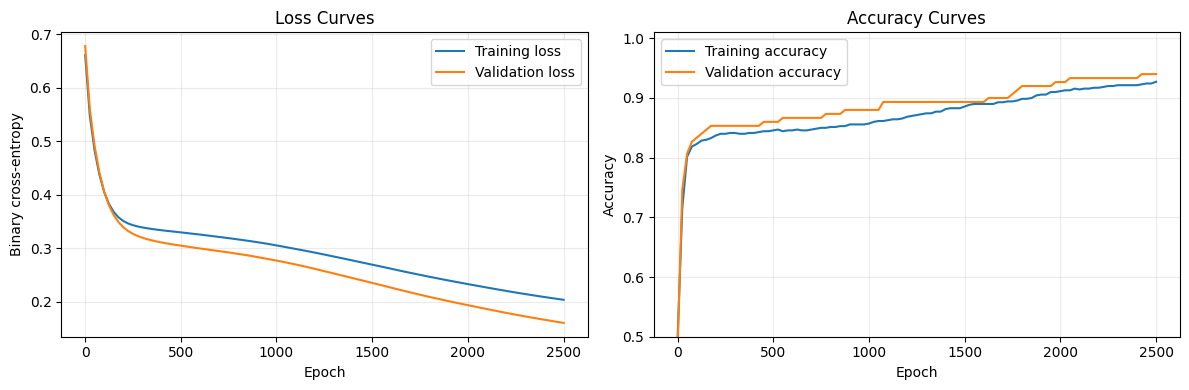

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["epoch"], history["train_loss"], label="Training loss")
axes[0].plot(history["epoch"], history["val_loss"], label="Validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary cross-entropy")
axes[0].set_title("Loss Curves")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(history["epoch"], history["train_accuracy"], label="Training accuracy")
axes[1].plot(history["epoch"], history["val_accuracy"], label="Validation accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.5, 1.01)
axes[1].set_title("Accuracy Curves")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 14. Prediction and evaluation

The sigmoid output is a probability. With the standard threshold $0.5$:

$$
\hat y_{\text{class}}=
\begin{cases}
1,&\hat y\ge 0.5,\\
0,&\hat y<0.5.
\end{cases}
$$

Accuracy alone is insufficient for many applications. We also report precision, recall, F1-score, ROC-AUC, and PR-AUC.

In [ ]:
def predict_probability(X, parameters):
    probability, _ = forward_propagation(X, parameters)
    return probability.ravel()


def evaluate_binary_classifier(y_true, probability, threshold=0.5):
    prediction = (probability >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, prediction),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probability),
        "pr_auc": average_precision_score(y_true, probability),
    }, prediction


test_probability = predict_probability(X_test_s, best_parameters)
scratch_metrics, test_prediction = evaluate_binary_classifier(y_test, test_probability)
pd.Series(scratch_metrics, name="NumPy FFNN").to_frame()

,NumPy FFNN
accuracy,0.960000
precision,0.972603
recall,0.946667
f1,0.959459
roc_auc,0.984000
pr_auc,0.987560


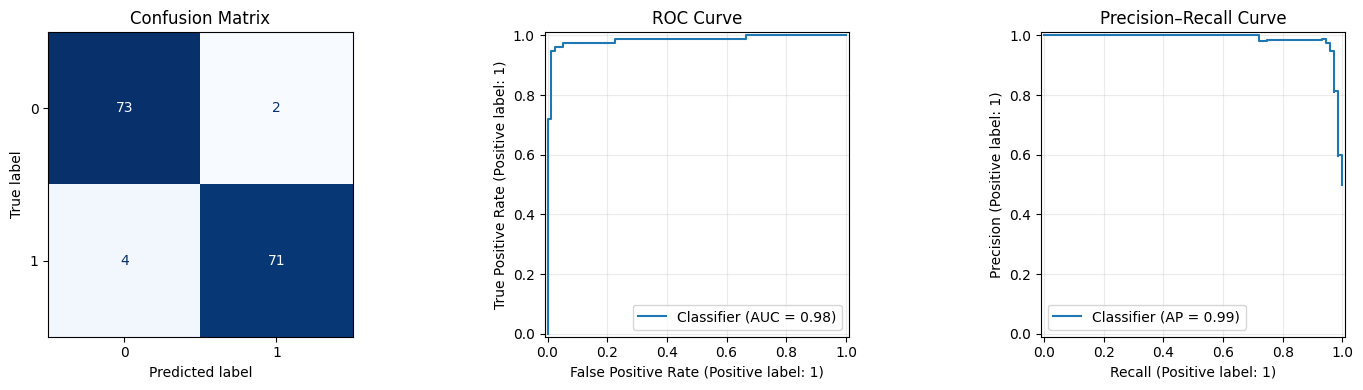

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay.from_predictions(y_test, test_prediction, cmap="Blues", colorbar=False, ax=axes[0])
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, test_probability, ax=axes[1])
axes[1].set_title("ROC Curve")
axes[1].grid(alpha=0.25)

PrecisionRecallDisplay.from_predictions(y_test, test_probability, ax=axes[2])
axes[2].set_title("Precision–Recall Curve")
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 15. Visualize the learned decision boundary

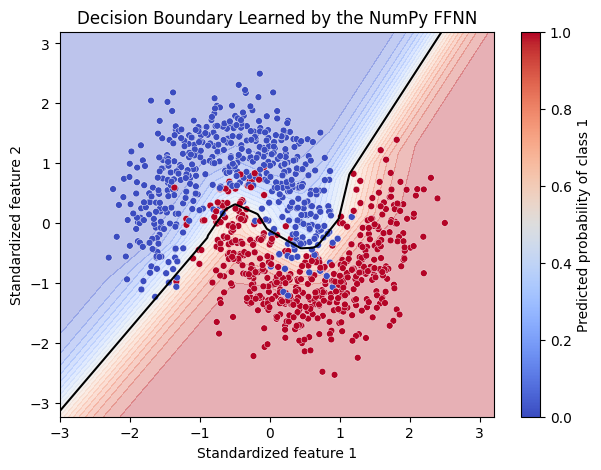

In [ ]:
def plot_decision_boundary(X, y, parameters, title):
    x_min, x_max = X[:, 0].min() - 0.7, X[:, 0].max() + 0.7
    y_min, y_max = X[:, 1].min() - 0.7, X[:, 1].max() + 0.7
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    probability = predict_probability(grid, parameters).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, probability, levels=np.linspace(0, 1, 21), cmap="coolwarm", alpha=0.35)
    plt.contour(xx, yy, probability, levels=[0.5], colors="black", linewidths=1.5)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=24, edgecolor="white", linewidth=0.3)
    plt.xlabel("Standardized feature 1")
    plt.ylabel("Standardized feature 2")
    plt.title(title)
    plt.colorbar(label="Predicted probability of class 1")
    plt.show()


X_all_s = scaler.transform(X)
plot_decision_boundary(
    X_all_s,
    y,
    best_parameters,
    "Decision Boundary Learned by the NumPy FFNN",
)

## 16. Hyperparameter experiment

The number of hidden neurons controls representation capacity, while the learning rate controls the size of each update. The validation set—not the test set—should be used to compare configurations.

In [ ]:
experiment_rows = []

for hidden_units in [2, 8, 32]:
    for learning_rate in [0.01, 0.05, 0.10]:
        experiment_parameters, experiment_history = train_ffnn(X_train_s,y_train,X_val_s,y_val,n_hidden=hidden_units,learning_rate=learning_rate,epochs=1200,seed=RANDOM_STATE,record_every=40,verbose=False)
        val_probability = predict_probability(X_val_s, experiment_parameters)
        experiment_rows.append({
            "hidden_units": hidden_units,
            "learning_rate": learning_rate,
            "best_val_loss": experiment_history["val_loss"].min(),
            "val_accuracy": accuracy_score(y_val, val_probability >= 0.5)
        })

experiment_table = pd.DataFrame(experiment_rows).sort_values(["val_accuracy", "best_val_loss"], ascending=[False, True])
experiment_table.reset_index(drop=True)

,hidden_units,learning_rate,best_val_loss,val_accuracy
0,32,0.10,0.136110,0.946667
1,8,0.10,0.165829,0.933333
2,32,0.05,0.219354,0.913333
3,8,0.05,0.261070,0.893333
4,32,0.01,0.271818,0.893333
5,2,0.10,0.275354,0.880000
6,2,0.05,0.309116,0.860000
7,2,0.01,0.366585,0.860000
8,8,0.01,0.328493,0.853333


## 17. Comparison with Scikit-learn

`MLPClassifier` provides an optimized reference implementation. Exact equality is not expected because initialization, optimizer details, regularization, batching, and stopping criteria differ. The comparison checks whether the from-scratch implementation behaves reasonably.

In [ ]:
sklearn_mlp = MLPClassifier(
    hidden_layer_sizes=(8,),
    activation="relu",
    solver="adam",
    learning_rate_init=0.01,
    max_iter=2000,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=RANDOM_STATE,
)

sklearn_mlp.fit(X_train_s, y_train)
sklearn_probability = sklearn_mlp.predict_proba(X_test_s)[:, 1]
sklearn_metrics, _ = evaluate_binary_classifier(y_test, sklearn_probability)

comparison = pd.DataFrame([scratch_metrics, sklearn_metrics],index=["NumPy FFNN", "Scikit-learn MLP"],)
comparison

,accuracy,precision,recall,f1,roc_auc,pr_auc
NumPy FFNN,0.960000,0.972603,0.946667,0.959459,0.984000,0.987560
Scikit-learn MLP,0.913333,0.942857,0.880000,0.910345,0.962667,0.969288


## 18. How to read the learning curves

| Observation | Likely meaning | Possible action |
|---|---|---|
| Both losses remain high | Underfitting or learning rate too small | Add capacity, train longer, or adjust learning rate |
| Training loss decreases but validation loss rises | Overfitting | Early stopping, regularization, or a smaller network |
| Loss oscillates strongly | Learning rate may be too large | Reduce the learning rate |
| Loss becomes `NaN` | Numerical instability or exploding values | Check scaling, clipping, learning rate, and gradients |
| Accuracy remains near chance | Wrong gradients, symmetry, or unsuitable activation | Run gradient checking and inspect shapes |

### Common implementation mistakes

- fitting the scaler on all data instead of the training set;
- forgetting to reshape labels to $(m,1)$;
- using element-wise multiplication where matrix multiplication is required;
- applying the ReLU derivative to $A^{[1]}$ instead of $Z^{[1]}$ without accounting for the definition;
- omitting division by the number of examples;
- changing weight matrices in place before all gradients are calculated;
- using the test set repeatedly for hyperparameter selection; and
- reporting only accuracy on an imbalanced dataset.

# Assignment: Implement a Feedforward Neural Network and Backpropagation

**Dataset:** Breast Cancer Wisconsin Diagnostic dataset from Scikit-learn  
**Task type:** Binary classification  
**Required architecture:** $30 \rightarrow 16 \rightarrow 1$  
**Hidden activation:** ReLU  
**Output activation:** Sigmoid  
**Loss:** Binary cross-entropy  
**Optimizer:** Full-batch gradient descent  
**Total marks:** 20

The positive label is `1` (benign) in the original Scikit-learn dataset. State this clearly when interpreting precision and recall.

## Assignment rules

1. Use NumPy for Tasks 3–8;
2. Use a fixed random state so that results are reproducible.
3. Fit preprocessing only on the training data.
4. Use validation data for model decisions and use the test set only for final evaluation.
5. Keep every output visible in the submitted notebook.

## Task 1 — Load the Breast Cancer dataset and print its shape, feature names, target names, and class counts. **[1 mark]**

In [ ]:
# Task 1 solution
# Write your code here.

## Task 2 — Create a stratified 70/15/15 split and standardize all features using statistics learned only from the training set. **[2 marks]**

In [ ]:
# Task 2 solution
# Write your code here.

## Task 3 — Implement stable sigmoid, ReLU, and ReLU-derivative functions using NumPy. **[2 marks]**

In [ ]:
# Task 3 solution
# Write your code here.

## Task 4 — Initialize the parameters of a $30 \rightarrow 16 \rightarrow 1$ neural network using He initialization and print the shape of each parameter. **[2 marks]**

In [ ]:
# Task 4 solution
# Write your code here.

## Task 5 — Implement forward propagation and print the shapes of $Z^{[1]}$, $A^{[1]}$, $Z^{[2]}$, and $A^{[2]}$ for five samples. **[3 marks]**

In [ ]:
# Task 5 solution
# Write your code here.

## Task 6 — Implement binary cross-entropy and calculate the initial training loss. **[1 mark]**

In [ ]:
# Task 6 solution
# Write your code here.

## Task 7 — Implement backpropagation for $dW^{[2]}$, $db^{[2]}$, $dW^{[1]}$, and $db^{[1]}$, then print all gradient shapes. **[4 marks]**

In [ ]:
# Task 7 solution
# Write your code here.

## Task 8 — Train the network for at least 2,000 epochs with gradient descent and plot training and validation loss. **[2 marks]**

In [ ]:
# Task 8 solution
# Write your code here.

## Task 9 — Evaluate the final test set using accuracy, precision, recall, F1, ROC-AUC, PR-AUC, and a confusion matrix. **[2 marks]**

In [ ]:
# Task 9 solution
# Write your code here.

## Task 10 — Compare the NumPy network with Scikit-learn `MLPClassifier` in one result table and write two observations. **[1 mark]**

In [ ]:
# Task 10 solution
# Write your code here.

## Marks distribution

| Task | Component | Marks |
|---:|---|---:|
| 1 | Dataset inspection | 1 |
| 2 | Leakage-free split and standardization | 2 |
| 3 | Activation functions | 2 |
| 4 | Parameter initialization | 2 |
| 5 | Forward propagation | 3 |
| 6 | Binary cross-entropy | 1 |
| 7 | Backpropagation | 4 |
| 8 | Training and learning curves | 2 |
| 9 | Test evaluation | 2 |
| 10 | Scikit-learn comparison and observations | 1 |
|  | **Total** | **20** |